# Addis Ababa University
# Advanced programming for Bioinformatics 
# Module 3 part 2: Biopython for Bioinformatics and Genomics


**Primary reference:** Official Biopython Tutorial and Cookbook  
https://biopython.org/docs/latest/Tutorial/

It focuses only on Biopython-based biological sequence analysis and related workflows.

## Learning Outcomes

By the end of this notebook, students should be able to:

1. Create and manipulate biological sequences using `Bio.Seq`
2. Use `SeqRecord` objects to store sequence metadata
3. Read and write FASTA files using `SeqIO`
4. Calculate sequence statistics such as length, base composition, and GC content
5. Perform transcription, translation, and reverse-complement operations
6. Parse GenBank-style annotations conceptually
7. Access NCBI Entrez records programmatically
8. Perform pairwise sequence alignment using Biopython
9. Read multiple sequence alignments using `AlignIO`
10. Read and visualize phylogenetic trees using `Phylo`
11. Build a mini Biopython-based sequence analysis pipeline

Register the environment as a Jupyter kernel

In [19]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

print("Biopython core modules imported successfully.")

Biopython core modules imported successfully.


# Part 1 — Biological Sequences with `Bio.Seq`

Biopython represents biological sequences using the `Seq` object. A `Seq` object behaves like a Python string but includes biological methods such as transcription, translation, and reverse-complement generation.

In [20]:
dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")


In [21]:
print("DNA sequence:", dna)

DNA sequence: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG


In [22]:
print("Length:", len(dna))

Length: 39


In [23]:
print("Type:", type(dna))

Type: <class 'Bio.Seq.Seq'>


## Classroom Question

Look at the sequence below:

`ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG`

What tells you that this is probably a DNA sequence and not an RNA sequence?

## Counting Bases

In [24]:
print("A:", dna.count("A"))
print("T:", dna.count("T"))
print("G:", dna.count("G"))
print("C:", dna.count("C"))

A: 9
T: 8
G: 14
C: 8


## GC Content

GC content is the percentage of bases in a DNA sequence that are either G or C. It is commonly used in genomics, genome assembly, primer design, and comparative genomics.

In [25]:
gc_content = (dna.count("G") + dna.count("C")) / len(dna) * 100
print(f"GC content: {gc_content:.2f}%")

GC content: 56.41%


## Exercise 1 — Write a GC Content Function

Write a function called `calculate_gc()` that accepts a DNA sequence and returns its GC content as a percentage.

In [26]:
# Exercise 1: write your solution here

def calculate_gc(sequence):
    gc_content = (sequence.count("G") + sequence.count("C")) / len(sequence) * 100
    return gc_content

# Test function
print(calculate_gc("ATGC"))

50.0


# Part 2 — Reverse Complement, Transcription, and Translation

In [27]:
print("Original DNA:        ", dna)
print("Complement:          ", dna.complement())
print("Reverse complement:  ", dna.reverse_complement())

Original DNA:         ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Complement:           TACCGGTAACATTACCCGGCGACTTTCCCACGGGCTATC
Reverse complement:   CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT


## Biological Interpretation

Reverse complements are important because DNA is double-stranded. Many bioinformatics analyses must consider both strands, especially in genome assembly, alignment, primer design, and variant interpretation.

In [28]:
rna = dna.transcribe()
print("RNA:", rna)

RNA: AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG


In [29]:
protein = dna.translate()
print("Protein:", protein)

Protein: MAIVMGR*KGAR*


## Translation with Stop Codons

The `*` symbol represents a stop codon.

In [30]:
print("Standard translation:", dna.translate())
print("Stop at first stop codon:", dna.translate(to_stop=True))

Standard translation: MAIVMGR*KGAR*
Stop at first stop codon: MAIVMGR


## Exercise 2 — Translate Your Own DNA Sequence

Create a DNA sequence that starts with `ATG`, translate it, and explain the resulting amino acid sequence.

In [31]:
# Exercise 2: write your code here

from Bio.Seq import Seq

student_dna = Seq("ATG")

# Translate DNA to protein
protein = student_dna.translate()

print("DNA Sequence:", student_dna)
print("Protein Sequence:", protein)

DNA Sequence: ATG
Protein Sequence: M


# Part 3 — SeqRecord Objects

A `SeqRecord` stores a sequence together with metadata such as ID, name, description, and annotations.

In [32]:
record = SeqRecord(
    dna,
    id="Example_001",
    name="ExampleGene",
    description="Example DNA sequence for MSc Biopython teaching"
)

print(record)

ID: Example_001
Name: ExampleGene
Description: Example DNA sequence for MSc Biopython teaching
Number of features: 0
Seq('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')


## Exercise 3 — Create a SeqRecord

Create your own `SeqRecord` with:

- an ID
- a name
- a description
- a DNA sequence

In [33]:
# Exercise 3: create your SeqRecord here

from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

tb_record = SeqRecord(
    Seq("ATGCGTACGTTAGC"),
    id="TB001",
    name="Mtb_gene",
    description="Mycobacterium tuberculosis DNA fragment"
)

print(tb_record)

ID: TB001
Name: Mtb_gene
Description: Mycobacterium tuberculosis DNA fragment
Number of features: 0
Seq('ATGCGTACGTTAGC')


# Part 4 — Reading and Writing FASTA Files with SeqIO

In [34]:
fasta_text = ">seq1 Example sequence 1\nATGCGTACGTAGCTAGCTAG\n>seq2 Example sequence 2\nATGCCCGGGTTTAAACCCGGG\n>seq3 Example sequence 3\nATATATATATATATATATATA\n"

with open("example_sequences.fasta", "w") as handle:
    handle.write(fasta_text)

print("Example FASTA file created.")

Example FASTA file created.


In [35]:
from Bio import SeqIO
for record in SeqIO.parse("example_sequences.fasta", "fasta"):
    print("ID:", record.id)
    print("Description:", record.description)
    print("Sequence:", record.seq)
    print("Length:", len(record.seq))
    print("GC content:", f"{calculate_gc(record.seq):.2f}%")
    print("-" * 40)

ID: seq1
Description: seq1 Example sequence 1
Sequence: ATGCGTACGTAGCTAGCTAG
Length: 20
GC content: 50.00%
----------------------------------------
ID: seq2
Description: seq2 Example sequence 2
Sequence: ATGCCCGGGTTTAAACCCGGG
Length: 21
GC content: 61.90%
----------------------------------------
ID: seq3
Description: seq3 Example sequence 3
Sequence: ATATATATATATATATATATA
Length: 21
GC content: 0.00%
----------------------------------------


## Exercise 4 — FASTA Summary Table

Read the example FASTA file and create a summary table with:

- sequence ID
- sequence length
- GC content
- number of A, T, G, and C bases

In [36]:
# Exercise 4: write your code here
from Bio import SeqIO
import pandas as pd

def calculate_gc(sequence):
    sequence = str(sequence).upper()
    return (sequence.count("G") + sequence.count("C")) / len(sequence) * 100

summary = []

for record in SeqIO.parse("example_sequences.fasta", "fasta"):
    seq = str(record.seq).upper()

    summary.append({
        "ID": record.id,
        "Length": len(seq),
        "GC_Content (%)": round(calculate_gc(seq), 2),
        "A": seq.count("A"),
        "T": seq.count("T"),
        "G": seq.count("G"),
        "C": seq.count("C")
    })

summary_df = pd.DataFrame(summary)

summary_df

,ID,Length,GC_Content (%),A,T,G,C
0,seq1,20,50.0,5,5,6,4
1,seq2,21,61.9,4,4,7,6
2,seq3,21,0.0,11,10,0,0


## Instructor Solution — FASTA Summary Table

In [37]:
import pandas as pd

summary = []

for record in SeqIO.parse("example_sequences.fasta", "fasta"):
    seq = str(record.seq).upper()
    summary.append({
        "id": record.id,
        "length": len(seq),
        "gc_content": calculate_gc(seq),
        "A": seq.count("A"),
        "T": seq.count("T"),
        "G": seq.count("G"),
        "C": seq.count("C")
    })

df = pd.DataFrame(summary)
df

,id,length,gc_content,A,T,G,C
0,seq1,20,50.000000,5,5,6,4
1,seq2,21,61.904762,4,4,7,6
2,seq3,21,0.000000,11,10,0,0


# Part 5 — Simple Visualization of Sequence Composition

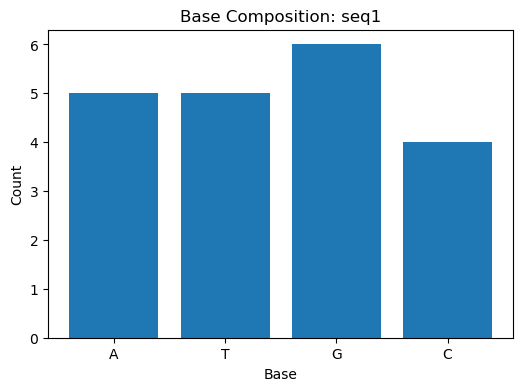

In [38]:
import matplotlib.pyplot as plt

record = next(SeqIO.parse("example_sequences.fasta", "fasta"))
seq = str(record.seq)

bases = ["A", "T", "G", "C"]
counts = [seq.count(base) for base in bases]

plt.figure(figsize=(6, 4))
plt.bar(bases, counts)
plt.xlabel("Base")
plt.ylabel("Count")
plt.title(f"Base Composition: {record.id}")
plt.show()

# Part 6 — Writing New FASTA Files

Biopython can also write sequence records to FASTA and other formats.

In [39]:
records = []

for record in SeqIO.parse("example_sequences.fasta", "fasta"):
    new_record = SeqRecord(
        record.seq.reverse_complement(),
        id=record.id + "_reverse_complement",
        description="Reverse complement sequence"
    )
    records.append(new_record)

SeqIO.write(records, "reverse_complements.fasta", "fasta")
print("Reverse complement FASTA file written.")

Reverse complement FASTA file written.


In [40]:
print(open("reverse_complements.fasta").read())

>seq1_reverse_complement Reverse complement sequence
CTAGCTAGCTACGTACGCAT
>seq2_reverse_complement Reverse complement sequence
CCCGGGTTTAAACCCGGGCAT
>seq3_reverse_complement Reverse complement sequence
TATATATATATATATATATAT



# Part 7 — GenBank Conceptual Parsing

GenBank records contain sequence plus rich annotations such as genes, CDS regions, products, and references.

In real analyses, GenBank files are commonly used to extract coding sequences, genes, proteins, and genomic features.

In [41]:
# Example structure only. This cell shows how GenBank parsing usually looks.

# for record in SeqIO.parse("example.gbk", "genbank"):
#     print(record.id, len(record.seq))
#     for feature in record.features:
#         if feature.type == "CDS":
#             print(feature.location)
#             print(feature.qualifiers.get("gene"))
#             print(feature.qualifiers.get("product"))

## Exercise 5 — Discussion

Why is GenBank more informative than FASTA for genome annotation analysis?

Discuss with examples such as:

- gene names
- CDS coordinates
- protein products
- organism metadata
- references

GenBank is more informative than FASTA for genome annotation because it contains both the DNA sequence and detailed biological annotations. While FASTA files only store sequence identifiers and sequences, GenBank files provide additional information such as gene names, CDS (coding sequence) coordinates, protein products, organism metadata, and scientific references.

For example, GenBank can identify a gene such as **rpoB**, specify its exact genomic coordinates, describe the protein it encodes, provide information about the source organism (e.g., *Mycobacterium tuberculosis*), and include references to the original research publication. In contrast, a FASTA file only contains the sequence data and lacks these annotations.

Therefore, GenBank is the preferred format for genome annotation and functional analysis, while FASTA is mainly used for storing and sharing nucleotide or protein sequences.

# Part 8 — Accessing NCBI with Entrez

Biopython provides `Bio.Entrez` for programmatic access to NCBI databases.

**Important:** Always set your email before using Entrez. NCBI requests this for responsible usage.

In [42]:
from Bio import Entrez

# Replace this with your institutional or student email before real use
Entrez.email = "naodm2006awet4@gmail.com"

print("Entrez email set to:", Entrez.email)

Entrez email set to: naodm2006awet4@gmail.com


In [43]:
# This cell requires internet access.
# It searches NCBI nucleotide records for Bos taurus mitochondrial genome.

handle = Entrez.esearch(db="nucleotide", term="Bos taurus mitochondrion complete genome", retmax=5)
results = Entrez.read(handle)
handle.close()

print(results["IdList"])

['3264155392', '3156478204', '2991366831', '2991366817', '2991366803']


In [44]:
id_list=results["IdList"]
handle = Entrez.efetch(
    db="nucleotide",
    id=id_list,
    rettype="fasta",
    retmode="text"
)

records = list(SeqIO.parse(handle, "fasta"))
handle.close()

print(records[0].description)
print(records[0].seq[:100])

PX725379.1 UNVERIFIED: Bos taurus isolate XBBO024 mitochondrion sequence
CCCATGCTCACACATAACTGTGCTGTCATACATTTGGTATTTTTTTATTTTGGGGGATGCTTGGACTCAGCTATGGCCGTCAAAGGCCCTGACCCGGAGC


## Exercise 6 — Entrez Search Design

Design Entrez search queries for:

1. Bos taurus mitochondrial genome
2. Capra hircus cytochrome b gene
3. Ovis aries complete mitochondrial genome
4. A gene of your research interest

In [45]:
from Bio import Entrez

# Always provide your email to NCBI
Entrez.email = "ke.metihabtamu@gmail.com"

# Entrez search queries
queries = {
    "Bos taurus mitochondrial genome":
        '"Bos taurus"[Organism] AND mitochondrion AND "complete genome"',

    "Capra hircus cytochrome b gene":
        '"Capra hircus"[Organism] AND "cytochrome b"[Gene]',

    "Ovis aries complete mitochondrial genome":
        '"Ovis aries"[Organism] AND mitochondrion AND "complete genome"',

    "Research gene of interest (rpoB)":
        '"Mycobacterium tuberculosis"[Organism] AND rpoB[Gene]'
}

# Execute searches
for name, query in queries.items():
    handle = Entrez.esearch(db="nucleotide", term=query)
    record = Entrez.read(handle)
    handle.close()

    print(f"\n{name}")
    print(f"Query: {query}")
    print(f"Number of matches: {record['Count']}")
    print(f"First 10 IDs: {record['IdList'][:10]}")


Bos taurus mitochondrial genome
Query: "Bos taurus"[Organism] AND mitochondrion AND "complete genome"
Number of matches: 1194
First 10 IDs: ['2991366831', '2991366817', '2991366803', '2991366789', '2991366775', '2991366761', '2991366747', '2991366733', '2991366719', '2991366705']

Capra hircus cytochrome b gene
Query: "Capra hircus"[Organism] AND "cytochrome b"[Gene]
Number of matches: 0
First 10 IDs: []

Ovis aries complete mitochondrial genome
Query: "Ovis aries"[Organism] AND mitochondrion AND "complete genome"
Number of matches: 646
First 10 IDs: ['1952003980', '2949323296', '2806396800', '2806396789', '2806396788', '2806396787', '2806396786', '2806396783', '2806396782', '2806396781']

Research gene of interest (rpoB)
Query: "Mycobacterium tuberculosis"[Organism] AND rpoB[Gene]
Number of matches: 14352
First 10 IDs: ['1268721758', '3337344069', '1463632785', '1450235614', '3336005994', '3328840598', '3328840596', '3328840594', '3328840592', '3328840590']


# Part 9 — Pairwise Sequence Alignment

Biopython provides modern pairwise alignment using `Bio.Align.PairwiseAligner`.

In [46]:
from Bio import Align

seq_a = "ATGCGTACGTAG"
seq_b = "ATGCGTTCGTAG"

aligner = Align.PairwiseAligner()
alignments = aligner.align(seq_a, seq_b)

print("Number of alignments:", len(alignments))
print("Best alignment score:", alignments[0].score)
print(alignments[0])

Number of alignments: 1
Best alignment score: 11.0
target            0 ATGCGTACGTAG 12
                  0 ||||||.||||| 12
query             0 ATGCGTTCGTAG 12



## Exercise 7 — Mutation Interpretation

Align the following sequences and identify the difference:

- Sequence 1: `ATGCCCTAG`
- Sequence 2: `ATGCGCTAG`

In [47]:
# Exercise 7: write your alignment code here
from Bio import Align

seq1 = "ATGCCCTAG"
seq2 = "ATGCGCTAG"

aligner = Align.PairwiseAligner()
alignments = aligner.align(seq1, seq2)

print("Number of alignments:", len(alignments))
print("Best alignment score:", alignments[0].score)
print(alignments[0])

Number of alignments: 1
Best alignment score: 8.0
target            0 ATGCCCTAG 9
                  0 ||||.|||| 9
query             0 ATGCGCTAG 9



# Part 10 — Multiple Sequence Alignment with AlignIO

`AlignIO` reads and writes multiple sequence alignment formats such as Clustal, Stockholm, PHYLIP, and FASTA alignments.

In [48]:
from Bio import AlignIO

alignment_fasta = ">sample1\nATGCGTACGTAG\n>sample2\nATGCGTTCGTAG\n>sample3\nATGCGTACGCAG\n"

with open("example_alignment.fasta", "w") as handle:
    handle.write(alignment_fasta)

alignment = AlignIO.read("example_alignment.fasta", "fasta")
print(alignment)
print("Number of sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())

Alignment with 3 rows and 12 columns
ATGCGTACGTAG sample1
ATGCGTTCGTAG sample2
ATGCGTACGCAG sample3
Number of sequences: 3
Alignment length: 12


In [49]:
%pip install logomaker

Note: you may need to restart the kernel to use updated packages.


<Figure size 1500x400 with 0 Axes>

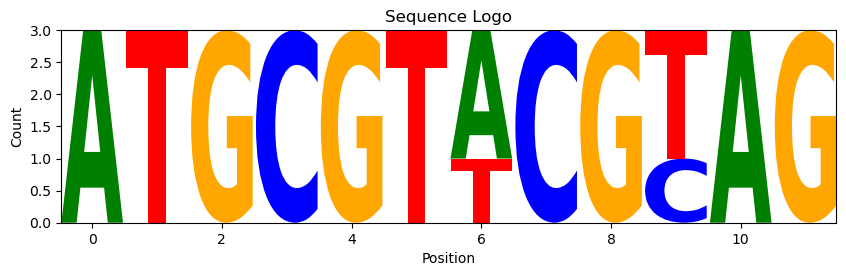

In [50]:
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
from collections import Counter

# Convert alignment into list of sequences
seqs = [str(record.seq) for record in alignment]

# Alignment length
L = len(seqs[0])

# Collect counts for each position
matrix = []

for i in range(L):
    column = [seq[i] for seq in seqs]
    counts = Counter(column)
    matrix.append(counts)

# Convert to DataFrame
df = pd.DataFrame(matrix).fillna(0)

# Optional: remove gaps
if "-" in df.columns:
    df = df.drop(columns="-")

# Create sequence logo
plt.figure(figsize=(15,4))
logomaker.Logo(df)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Sequence Logo")
plt.show()

## Exercise 8 — Alignment Statistics

For each column in the alignment, count how many different bases are present. Which columns are variable?

In [51]:
# Exercise 8: write your code here
from collections import Counter

# Alignment length
L = alignment.get_alignment_length()

print("Column\tBases\tDifferent Bases\tVariable?")

for i in range(L):
    column = alignment[:, i]          # Get all bases at position i
    counts = Counter(column)

    # Ignore gaps if desired
    counts.pop("-", None)

    num_bases = len(counts)
    variable = "Yes" if num_bases > 1 else "No"

    print(f"{i+1}\t{dict(counts)}\t{num_bases}\t\t{variable}")

Column	Bases	Different Bases	Variable?
1	{'A': 3}	1		No
2	{'T': 3}	1		No
3	{'G': 3}	1		No
4	{'C': 3}	1		No
5	{'G': 3}	1		No
6	{'T': 3}	1		No
7	{'A': 2, 'T': 1}	2		Yes
8	{'C': 3}	1		No
9	{'G': 3}	1		No
10	{'T': 2, 'C': 1}	2		Yes
11	{'A': 3}	1		No
12	{'G': 3}	1		No


# Part 11 — Phylogenetic Trees with Bio.Phylo

Biopython can read, write, and display phylogenetic trees in formats such as Newick and PhyloXML.

In [52]:
from Bio import Phylo
from io import StringIO

newick = "((sample1:0.1,sample2:0.2):0.3,sample3:0.4);"
tree = Phylo.read(StringIO(newick), "newick")

Phylo.draw_ascii(tree)

                                            _____________ sample1
  _________________________________________|
_|                                         |___________________________ sample2
 |
 |_______________________________________________________ sample3



## Exercise 9 — Tree Interpretation

Based on the tree above, which two samples are more closely related? Why?

Sample1 and Sample2 are the most closely related samples because they share the most recent common ancestor on the phylogenetic tree. They branch from the same node before joining with Sample3, indicating a closer evolutionary relationship. Sample3 diverged earlier and is therefore more distantly related.

# Part 12 — Mini Biopython Pipeline

Now we combine several skills into one mini workflow.

The pipeline will:

1. Read a FASTA file
2. Calculate sequence length
3. Calculate GC content
4. Translate sequences that appear to be coding DNA
5. Save a summary table

In [53]:
def analyze_fasta(input_fasta, output_csv):
    results = []
    
    for record in SeqIO.parse(input_fasta, "fasta"):
        seq = record.seq
        seq_string = str(seq).upper()
        
        translated = ""
        if seq_string.startswith("ATG") and len(seq_string) % 3 == 0:
            translated = str(seq.translate(to_stop=False))
        
        results.append({
            "id": record.id,
            "description": record.description,
            "length": len(seq),
            "gc_content": calculate_gc(seq),
            "starts_with_ATG": seq_string.startswith("ATG"),
            "length_multiple_of_3": len(seq_string) % 3 == 0,
            "translated_sequence": translated
        })
    
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    return df

pipeline_results = analyze_fasta("example_sequences.fasta", "sequence_summary.csv")
pipeline_results

,id,description,length,gc_content,starts_with_ATG,length_multiple_of_3,translated_sequence
0,seq1,seq1 Example sequence 1,20,50.000000,True,False,
1,seq2,seq2 Example sequence 2,21,61.904762,True,True,MPGFKPG
2,seq3,seq3 Example sequence 3,21,0.000000,False,True,


## Exercise 10 — Improve the Pipeline

Modify the pipeline to also report:

- reverse complement
- number of stop codons in translated protein
- whether the sequence contains ambiguous bases such as N
- AT content
- sequence category: high GC, medium GC, or low GC

In [54]:
# Exercise 10: improve the pipeline here
from Bio import SeqIO
import pandas as pd

def calculate_gc(sequence):
    sequence = str(sequence).upper()
    return (sequence.count("G") + sequence.count("C")) / len(sequence) * 100

def calculate_at(sequence):
    sequence = str(sequence).upper()
    return (sequence.count("A") + sequence.count("T")) / len(sequence) * 100

def gc_category(gc):
    if gc >= 60:
        return "High GC"
    elif gc >= 40:
        return "Medium GC"
    else:
        return "Low GC"

def analyze_fasta(input_fasta, output_csv):
    results = []

    for record in SeqIO.parse(input_fasta, "fasta"):
        seq = record.seq
        seq_string = str(seq).upper()

        # Translation
        translated = ""
        stop_codons = 0

        if seq_string.startswith("ATG") and len(seq_string) % 3 == 0:
            translated = str(seq.translate(to_stop=False))
            stop_codons = translated.count("*")

        # Calculate statistics
        gc = calculate_gc(seq)
        at = calculate_at(seq)

        results.append({
            "id": record.id,
            "description": record.description,
            "length": len(seq),

            "gc_content": round(gc, 2),
            "at_content": round(at, 2),

            "gc_category": gc_category(gc),

            "starts_with_ATG": seq_string.startswith("ATG"),
            "length_multiple_of_3": len(seq_string) % 3 == 0,

            "contains_N": "N" in seq_string,

            "reverse_complement": str(seq.reverse_complement()),

            "translated_sequence": translated,
            "stop_codon_count": stop_codons
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    return df

# Run pipeline
pipeline_results = analyze_fasta(
    "example_sequences.fasta",
    "sequence_summary.csv"
)

pipeline_results

,id,description,length,gc_content,at_content,gc_category,starts_with_ATG,length_multiple_of_3,contains_N,reverse_complement,translated_sequence,stop_codon_count
0,seq1,seq1 Example sequence 1,20,50.0,50.0,Medium GC,True,False,False,CTAGCTAGCTACGTACGCAT,,0
1,seq2,seq2 Example sequence 2,21,61.9,38.1,High GC,True,True,False,CCCGGGTTTAAACCCGGGCAT,MPGFKPG,0
2,seq3,seq3 Example sequence 3,21,0.0,100.0,Low GC,False,True,False,TATATATATATATATATATAT,,0


# Final Challenge Project

Complete one of the following mini-projects using Biopython:

## Option A — Genome FASTA Summary
Search for the smallest genome size data from a public database, download a genome FASTA file and generate a summary table containing sequence length, GC content, and base composition.

## Option B — CDS Extraction from GenBank
Search for the smallest genome size data from a public database, download a GenBank file and extract all CDS sequences into FASTA format.

## Option C — Mitochondrial Genome Comparison
Search for the four smallest genome size data from a public database, download mitochondrial genome sequences from multiple species and compare length and GC content.

## Option D — Alignment and Phylogenetics
Create a multiple sequence alignment and draw a phylogenetic tree.

## Option E — Livestock Gene Analysis
Retrieve sequences for a livestock gene from pubic database of interest and perform sequence translation and comparison.

CDS Extraction from GenBank

Objective: Search for the smallest genome in NCBI, download its GenBank

In [2]:
from Bio import Entrez, SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import os, textwrap

print("✅ All dependencies loaded successfully!")

✅ All dependencies loaded successfully!


In [3]:
#Configure NCBI Entrez
Entrez.email = "ke.metihabtamu@gmail.com"  
Entrez.tool  = "CDS_Extraction_Pipeline"
print(f"📧 Entrez configured with email: {Entrez.email}")

📧 Entrez configured with email: ke.metihabtamu@gmail.com


In [10]:
#Search NCBI for the Smallest Complete Genome
search_query = (
    '"complete genome"[Title] '
    'NOT plasmid[Title] '
    'NOT segment[Title] '
    'NOT MAG[Title] '
    'AND bacteria[Filter] '
    'AND biomol_genomic[PROP] '
    'AND 100000:250000[SLEN]'   # sequence length 100–250 kb
)
print("🔍 Searching NCBI Nucleotide database...")
print(f"   Query: {search_query}\n")
handle = Entrez.esearch(
    db="nucleotide",
    term=search_query,
    sort="SLEN",          # sort by sequence length
    retmax=10,            # get top 10 smallest
    usehistory="y"
)
search_results = Entrez.read(handle)
handle.close()
id_list = search_results["IdList"]
print(f"✅ Found {search_results['Count']} total results.")
print(f"   Retrieved top {len(id_list)} smallest IDs: {id_list}\n")
# Fetch summary info for the top hits
handle = Entrez.esummary(db="nucleotide", id=",".join(id_list))
summaries = Entrez.read(handle)
handle.close()
print("=" * 80)
print(f"{'#':<4} {'Accession':<18} {'Length (bp)':>12}   Title")
print("=" * 80)
for i, s in enumerate(summaries, 1):
    print(f"{i:<4} {s['Caption']:<18} {s['Length']:>12,}   {s['Title'][:60]}")
print("=" * 80)
# Pick the smallest one
smallest = summaries[0]
accession = smallest["Caption"]
genome_length = smallest["Length"]
genome_title = smallest["Title"]
print(f"\n🏆 Smallest genome selected:")
print(f"   Accession : {accession}")
print(f"   Length    : {genome_length:,} bp")
print(f"   Title     : {genome_title}")

🔍 Searching NCBI Nucleotide database...
   Query: "complete genome"[Title] NOT plasmid[Title] NOT segment[Title] NOT MAG[Title] AND bacteria[Filter] AND biomol_genomic[PROP] AND 100000:250000[SLEN]

✅ Found 310 total results.
   Retrieved top 10 smallest IDs: ['158633136', '1399734326', '1402595711', '684178979', '1399734319', '1402580186', '292667677', '1399734320', '1402603615', '2498966212']

#    Accession           Length (bp)   Title
1    CP000770                245,530   Candidatus Sulcia muelleri GWSS, complete genome
2    CP029022                245,295   Candidatus Karelsulcia muelleri isolate SMVAGTER chromosome,
3    NZ_CP029022             245,295   Candidatus Karelsulcia muelleri isolate SMVAGTER chromosome,
4    CP008986                244,618   Candidatus Sulcia muelleri strain BGSS, complete genome
5    CP029015                244,201   Candidatus Karelsulcia muelleri isolate SMKOSYEZ chromosome,
6    NZ_CP029015             244,201   Candidatus Karelsulcia muelleri is

In [11]:
# Download the GenBank File
output_dir = "genbank_output"
os.makedirs(output_dir, exist_ok=True)
gbk_filename = os.path.join(output_dir, f"{accession}.gbk")
print(f"⬇️  Downloading GenBank file for {accession} ...")
handle = Entrez.efetch(
    db="nucleotide",
    id=accession,
    rettype="gb",
    retmode="text"
)
with open(gbk_filename, "w") as f:
    f.write(handle.read())
handle.close()
file_size = os.path.getsize(gbk_filename)
print(f"✅ Saved: {gbk_filename}  ({file_size:,} bytes)")

⬇️  Downloading GenBank file for CP000770 ...
✅ Saved: genbank_output\CP000770.gbk  (566,552 bytes)


In [12]:
#Parse GenBank & Extract All CDS Features
print(f"🔬 Parsing GenBank file: {gbk_filename}\n")
record = SeqIO.read(gbk_filename, "genbank")
print(f"   Organism    : {record.annotations.get('organism', 'N/A')}")
print(f"   Description : {record.description}")
print(f"   Seq Length  : {len(record.seq):,} bp")
print(f"   Total Features: {len(record.features)}\n")
# Extract CDS features
cds_records = []
cds_count = 0
for feature in record.features:
    if feature.type != "CDS":
        continue
    cds_count += 1
    # Extract qualifiers
    gene      = feature.qualifiers.get("gene", ["unknown_gene"])[0]
    product   = feature.qualifiers.get("product", ["unknown_product"])[0]
    protein_id = feature.qualifiers.get("protein_id", ["no_protein_id"])[0]
    locus_tag = feature.qualifiers.get("locus_tag", ["no_locus_tag"])[0]
    translation = feature.qualifiers.get("translation", [None])[0]
    # Get nucleotide sequence of the CDS
    nuc_seq = feature.location.extract(record.seq)
    # Build a FASTA header with useful metadata
    header = (
        f"{accession}_CDS{cds_count:04d} "
        f"gene={gene} "
        f"product={product} "
        f"protein_id={protein_id} "
        f"locus_tag={locus_tag} "
        f"location={feature.location} "
        f"length={len(nuc_seq)}bp"
    )
    cds_record = SeqRecord(
        seq=nuc_seq,
        id=f"{accession}_CDS{cds_count:04d}",
        description=header.split(" ", 1)[1],
    )
    cds_records.append(cds_record)
print(f"✅ Extracted {cds_count} CDS features")
# Show a summary table
print(f"\n{'#':<5} {'Gene':<15} {'Product':<40} {'Length (bp)':>12}")
print("-" * 75)
for i, feat in enumerate(record.features):
    if feat.type != "CDS":
        continue
    gene = feat.qualifiers.get("gene", ["—"])[0]
    prod = feat.qualifiers.get("product", ["—"])[0]
    length = len(feat.location.extract(record.seq))
    print(f"{i:<5} {gene:<15} {prod[:38]:<40} {length:>12,}")

🔬 Parsing GenBank file: genbank_output\CP000770.gbk

   Organism    : Candidatus Karelsulcia muelleri GWSS
   Description : Candidatus Sulcia muelleri GWSS, complete genome
   Seq Length  : 245,530 bp
   Total Features: 532

✅ Extracted 227 CDS features

#     Gene            Product                                   Length (bp)
---------------------------------------------------------------------------
2     lipB            lipoyl-[acyl-carrier-protein]-protein-            687
4     valS            valyl-tRNA synthetase                           2,613
6     ftsH            putative ATP-dependent metalloprotease          1,875
8     dnaN            DNA polymerase III, beta subunit                1,101
10    pheT            phenylalanyl-tRNA synthetase beta subu          2,223
12    aroB            3-dehydroquinate synthase                       1,077
14    gyrA            type IV DNA gyrase A subunit                    2,463
16    —               putative methyltransferase             

In [13]:
#Write CDS Sequences to FASTA File
fasta_filename = os.path.join(output_dir, f"{accession}_CDS.fasta")
count = SeqIO.write(cds_records, fasta_filename, "fasta")
fasta_size = os.path.getsize(fasta_filename)
print(f"✅ Wrote {count} CDS sequences to: {fasta_filename}  ({fasta_size:,} bytes)")

✅ Wrote 227 CDS sequences to: genbank_output\CP000770_CDS.fasta  (269,851 bytes)


In [14]:
#Preview the Output FASTA
print(f"📄 Preview of {fasta_filename}:\n")
print("=" * 80)
with open(fasta_filename, "r") as f:
    lines = f.readlines()
    # Show first 40 lines
    for line in lines[:40]:
        print(line, end="")
if len(lines) > 40:
    print(f"\n... ({len(lines) - 40} more lines)")
print("\n" + "=" * 80)

📄 Preview of genbank_output\CP000770_CDS.fasta:

>CP000770_CDS0001 gene=lipB product=lipoyl-[acyl-carrier-protein]-protein-N- lipoyltransferase protein_id=ABS30433.2 locus_tag=SMGWSS_001 location=[0:687](+) length=687bp
TTGTATAAAATAAATATAAAAGTTTTTTTTGAAGACTTGAATAAAAAAGATTTTCAAGAA
ACTTGGGTTTATCAAAAAAAAATATTTAATATTATAATTAATATTAAAATCTATAATAGA
TTTTTAAAAAAAAAAATAAAAATTGTACCTAATTATTTATTATTTGTAGAACACAACAAT
GTTTATACATTAGGTAAAATAGGATCATATAAAAATTTATTATTGAATAATAAAAATATT
ATAATTTATAAAATTGATAGAGGAGGAGATATTACATATCATGGTCCTGGTCAATTAGTT
TGTTATCCTATATTTGATATTATTAATTTTTATTTAGACATAAATAAATATTTACGTATT
ATTGAAGAAGTTATAATTAAACTTATATATAATTATTGTATTAAAGGATATAGAATATCT
AATAAAACAGGGGTATGGGTATATACTAGGAAAATATGTGCAATTGGTATTAAAGTAAGT
AGATTTGTAACAATGCATGGTTTTGCGTTAAATGTAAATACAGATTTAAGTTATTTTAAT
AATATAATTCCATGTGGAATAAAAAAGAAAAGTGTTACATCAATAAATGTAGAAAAAATA
AATAATAAAATTGATATGTATGAAGTAAAATTCATTTTAAAAAAAAAATTAATTTTTTAT
TTAAAATTAAATTTATCTAATTTCTAA
>CP000770_CDS0002 gene=valS product=valyl-tRNA synthetase protein_id=ABS30434.2 l

In [15]:
# Summary Statistics
lengths = [len(r.seq) for r in cds_records]
print("📊 CDS Extraction Summary")
print("=" * 50)
print(f"   Organism        : {record.annotations.get('organism', 'N/A')}")
print(f"   Genome Accession: {accession}")
print(f"   Genome Length   : {len(record.seq):,} bp")
print(f"   Total CDS       : {len(cds_records)}")
print(f"   Shortest CDS    : {min(lengths):,} bp")
print(f"   Longest CDS     : {max(lengths):,} bp")
print(f"   Average CDS     : {sum(lengths)/len(lengths):,.1f} bp")
print(f"   Total CDS bp    : {sum(lengths):,} bp")
coding_pct = (sum(lengths) / len(record.seq)) * 100
print(f"   Coding Density  : {coding_pct:.1f}%")
print("=" * 50)
print(f"\n📁 Output files:")
print(f"   GenBank : {os.path.abspath(gbk_filename)}")
print(f"   FASTA   : {os.path.abspath(fasta_filename)}")
print(f"\n🎉 Pipeline complete!")

📊 CDS Extraction Summary
   Organism        : Candidatus Karelsulcia muelleri GWSS
   Genome Accession: CP000770
   Genome Length   : 245,530 bp
   Total CDS       : 227
   Shortest CDS    : 117 bp
   Longest CDS     : 4,524 bp
   Average CDS     : 996.3 bp
   Total CDS bp    : 226,164 bp
   Coding Density  : 92.1%

📁 Output files:
   GenBank : c:\Users\dell\Documents\GitHub\Advanced-Programming\genbank_output\CP000770.gbk
   FASTA   : c:\Users\dell\Documents\GitHub\Advanced-Programming\genbank_output\CP000770_CDS.fasta

🎉 Pipeline complete!
